In [5]:
# === 装这周需要的包 ===
!pip install pandas seaborn scikit-learn lightgbm tqdm -q -i https://pypi.tuna.tsinghua.edu.cn/simple
print("✅ 包安装完成")

✅ 包安装完成


In [7]:
import sys
print("Python 路径:", sys.executable)
print("Python 版本:", sys.version)

# 检查哪些包能用
import importlib
for pkg in ['pandas', 'numpy', 'matplotlib', 'seaborn', 'sklearn', 'lightgbm']:
    try:
        importlib.import_module(pkg)
        print(f"✅ {pkg}")
    except ImportError:
        print(f"❌ {pkg}")

Python 路径: /root/miniconda3/bin/python
Python 版本: 3.10.8 (main, Nov 24 2022, 14:13:03) [GCC 11.2.0]
✅ pandas
✅ numpy
✅ matplotlib
✅ seaborn
✅ sklearn
✅ lightgbm


In [8]:
# === Cell 1: 导入工具 + 设置 ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# pandas 显示设置
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.2f}'.format)

# 画图美化
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.unicode_minus'] = False

# 项目根目录(notebook 在 notebooks/ 下,data 在上一级)
DATA_DIR = "../data/raw"

print("✅ 工具加载完成")
print(f"   pandas:     {pd.__version__}")
print(f"   numpy:      {np.__version__}")
print(f"   matplotlib: {plt.matplotlib.__version__}")

✅ 工具加载完成
   pandas:     2.3.3
   numpy:      1.26.4
   matplotlib: 3.9.0


In [9]:
# === Cell 2: 加载训练数据 ===
import time

print("正在加载 train.csv ...")
start = time.time()

train = pd.read_csv(f"{DATA_DIR}/BPC_5core_train.csv")

elapsed = time.time() - start
print(f"✅ train 加载完成,用时 {elapsed:.1f} 秒")
print(f"   形状: {train.shape}")
print(f"   内存占用: {train.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

正在加载 train.csv ...
✅ train 加载完成,用时 3.0 秒
   形状: (5165289, 4)
   内存占用: 827.6 MB


In [11]:
# === Cell 3: Q2 - 整体规模 ===
n_interactions = len(train)
n_users = train['user_id'].nunique()
n_items = train['parent_asin'].nunique()

density = n_interactions / (n_users * n_items)

print("【整体规模(train 集)】")
print(f"  总交互数:            {n_interactions:>15,}")
print(f"  独立用户数:          {n_users:>15,}")
print(f"  独立商品数:          {n_items:>15,}")
print()
print("【密度指标】")
print(f"  平均每用户交互数:    {n_interactions/n_users:>15.2f}")
print(f"  平均每商品被交互数:  {n_interactions/n_items:>15.2f}")
print(f"  数据稀疏度:          {1 - density:>15.6%}")
print(f"  数据密度(对比 All_Beauty 1.11): {n_interactions/n_users:>4.2f} 倍更密")

【整体规模(train 集)】
  总交互数:                  5,165,289
  独立用户数:                  729,576
  独立商品数:                  207,385

【密度指标】
  平均每用户交互数:               7.08
  平均每商品被交互数:            24.91
  数据稀疏度:               99.996586%
  数据密度(对比 All_Beauty 1.11): 7.08 倍更密


【用户活跃度统计】
  用户数:           729,576
  最少交互:               3   (5-core 应保证 ≥5)
  最多交互:            2349
  中位数:                 5
  平均数:              7.08
  90 分位数:            12
  99 分位数:            39



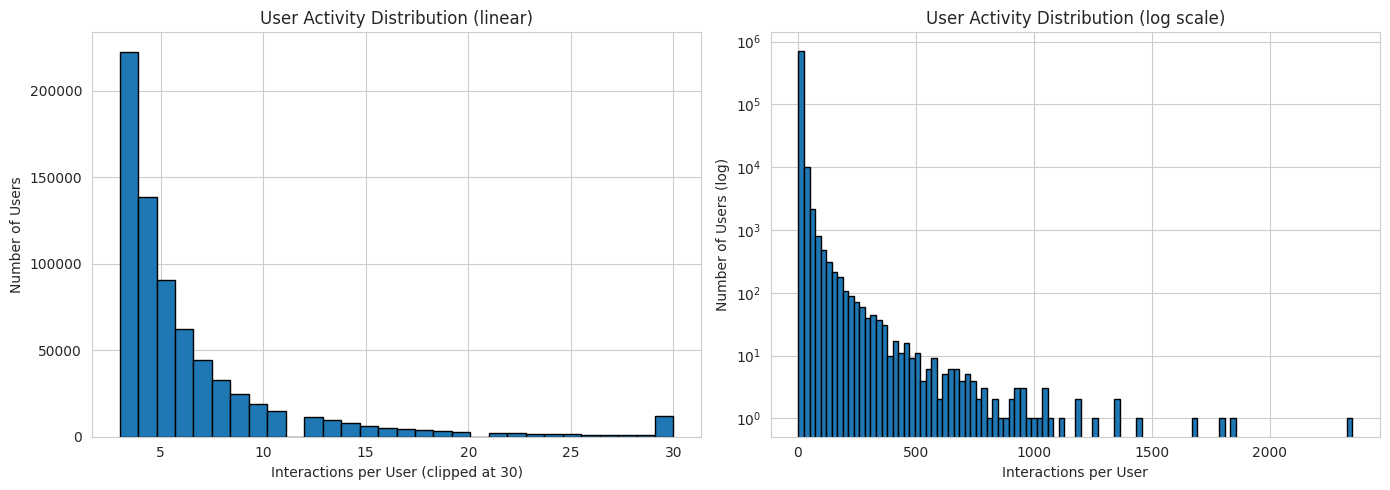

In [12]:
# === Cell 4: Q3 - 用户活跃度分布 ===

# 每个用户的交互次数
user_counts = train.groupby('user_id').size()

print("【用户活跃度统计】")
print(f"  用户数:        {len(user_counts):>10,}")
print(f"  最少交互:      {user_counts.min():>10}   (5-core 应保证 ≥5)")
print(f"  最多交互:      {user_counts.max():>10}")
print(f"  中位数:        {user_counts.median():>10.0f}")
print(f"  平均数:        {user_counts.mean():>10.2f}")
print(f"  90 分位数:    {user_counts.quantile(0.90):>10.0f}")
print(f"  99 分位数:    {user_counts.quantile(0.99):>10.0f}")
print()

# 画分布图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图: 线性坐标(看主体分布)
axes[0].hist(user_counts.clip(upper=30), bins=30, edgecolor='black')
axes[0].set_xlabel('Interactions per User (clipped at 30)')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('User Activity Distribution (linear)')

# 右图: 对数坐标(看长尾)
axes[1].hist(user_counts, bins=100, edgecolor='black')
axes[1].set_xlabel('Interactions per User')
axes[1].set_ylabel('Number of Users (log)')
axes[1].set_yscale('log')
axes[1].set_title('User Activity Distribution (log scale)')

plt.tight_layout()
plt.show()

In [13]:
# 简单验证(可选,不画图,1 秒)
print("用户交互数为 3-5 的占比:")
for n in [3, 4, 5]:
    count = (user_counts == n).sum()
    pct = count / len(user_counts) * 100
    print(f"  {n} 次: {count:>6,} 个用户 ({pct:.1f}%)")
    

用户交互数为 3-5 的占比:
  3 次: 222,658 个用户 (30.5%)
  4 次: 138,729 个用户 (19.0%)
  5 次: 90,877 个用户 (12.5%)


【商品热门度统计】
  商品数:           207,385
  最少被交互:             1
  最多被交互:          5986
  中位数:                10
  平均数:             24.91
  90 分位数:            45
  99 分位数:           273

【二八定律检验】
  Top 20% 商品 (41,477 个) 贡献了 70.5% 的交互


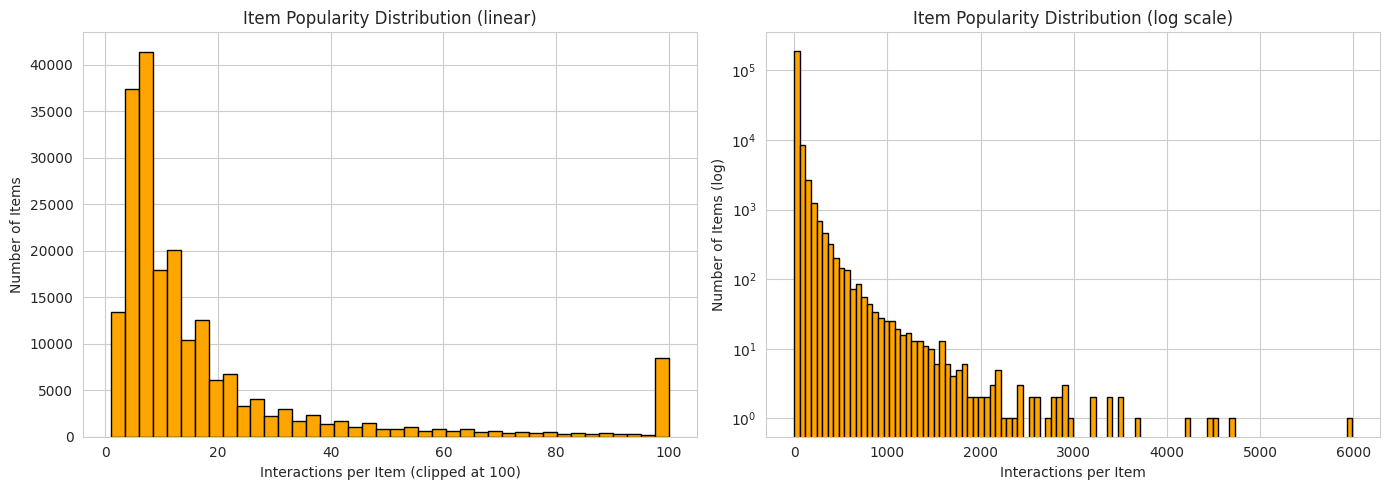

In [14]:
# === Cell 5: Q4 - 商品热门度分布 ===
item_counts = train.groupby('parent_asin').size()

print("【商品热门度统计】")
print(f"  商品数:        {len(item_counts):>10,}")
print(f"  最少被交互:    {item_counts.min():>10}")
print(f"  最多被交互:    {item_counts.max():>10}")
print(f"  中位数:        {item_counts.median():>10.0f}")
print(f"  平均数:        {item_counts.mean():>10.2f}")
print(f"  90 分位数:    {item_counts.quantile(0.90):>10.0f}")
print(f"  99 分位数:    {item_counts.quantile(0.99):>10.0f}")
print()

# 二八定律检验
top20_pct = int(len(item_counts) * 0.2)
top20_share = item_counts.nlargest(top20_pct).sum() / item_counts.sum() * 100
print(f"【二八定律检验】")
print(f"  Top 20% 商品 ({top20_pct:,} 个) 贡献了 {top20_share:.1f}% 的交互")

# 画图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(item_counts.clip(upper=100), bins=40, edgecolor='black', color='orange')
axes[0].set_xlabel('Interactions per Item (clipped at 100)')
axes[0].set_ylabel('Number of Items')
axes[0].set_title('Item Popularity Distribution (linear)')

axes[1].hist(item_counts, bins=100, edgecolor='black', color='orange')
axes[1].set_xlabel('Interactions per Item')
axes[1].set_ylabel('Number of Items (log)')
axes[1].set_yscale('log')
axes[1].set_title('Item Popularity Distribution (log scale)')

plt.tight_layout()
plt.show()

【评分分布】
rating
1.00     371603
2.00     253421
3.00     431408
4.00     718922
5.00    3389935
Name: count, dtype: int64

【占比】
  1 星:  7.19%  ███████
  2 星:  4.91%  ████
  3 星:  8.35%  ████████
  4 星: 13.92%  █████████████
  5 星: 65.63%  █████████████████████████████████████████████████████████████████


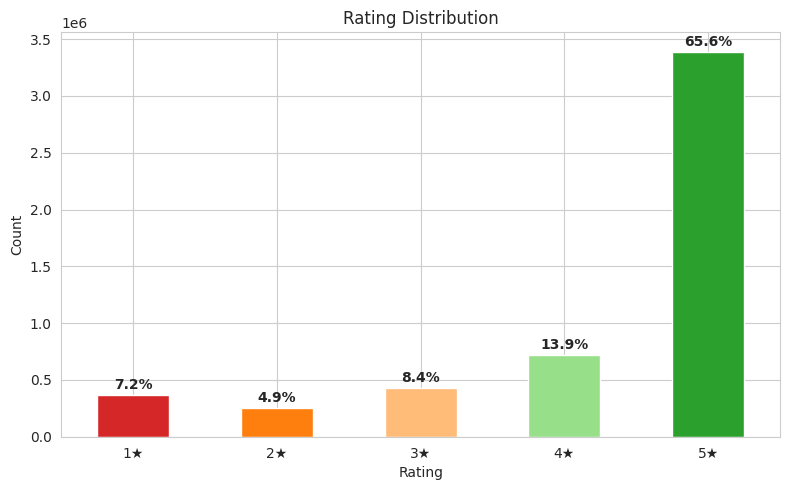

In [15]:
# === Cell 6: Q5 - 评分分布 ===
rating_dist = train['rating'].value_counts().sort_index()
print("【评分分布】")
print(rating_dist)
print()
print("【占比】")
rating_pct = train['rating'].value_counts(normalize=True).sort_index() * 100
for rating, pct in rating_pct.items():
    bar = '█' * int(pct)
    print(f"  {rating:.0f} 星: {pct:5.2f}%  {bar}")

# 画图
fig, ax = plt.subplots(figsize=(8, 5))
rating_dist.plot(kind='bar', color=['#d62728', '#ff7f0e', '#ffbb78', '#98df8a', '#2ca02c'], ax=ax)
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
ax.set_title('Rating Distribution')
ax.set_xticklabels([f'{int(r)}★' for r in rating_dist.index], rotation=0)

# 加上百分比标签
for i, v in enumerate(rating_dist.values):
    ax.text(i, v + 50000, f'{v/rating_dist.sum()*100:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

【时间跨度】
  最早交互: 2000-12-20 01:09:42
  最晚交互: 2023-09-12 02:39:46.751000
  时间跨度: 8301 天 (≈ 22.7 年)

【按年分布】
  2000:          1  
  2002:          9  
  2003:         24  
  2004:        111  
  2005:        178  
  2006:        285  
  2007:        821  
  2008:      1,666  
  2009:      3,026  
  2010:      6,985  
  2011:     18,788  █
  2012:     44,933  ███
  2013:    132,233  █████████
  2014:    243,203  ████████████████
  2015:    403,468  ███████████████████████████
  2016:    470,221  ████████████████████████████████
  2017:    456,594  ███████████████████████████████
  2018:    473,593  ████████████████████████████████
  2019:    624,094  ██████████████████████████████████████████
  2020:    730,202  ██████████████████████████████████████████████████
  2021:    639,055  ███████████████████████████████████████████
  2022:    684,683  ██████████████████████████████████████████████
  2023:    231,116  ███████████████


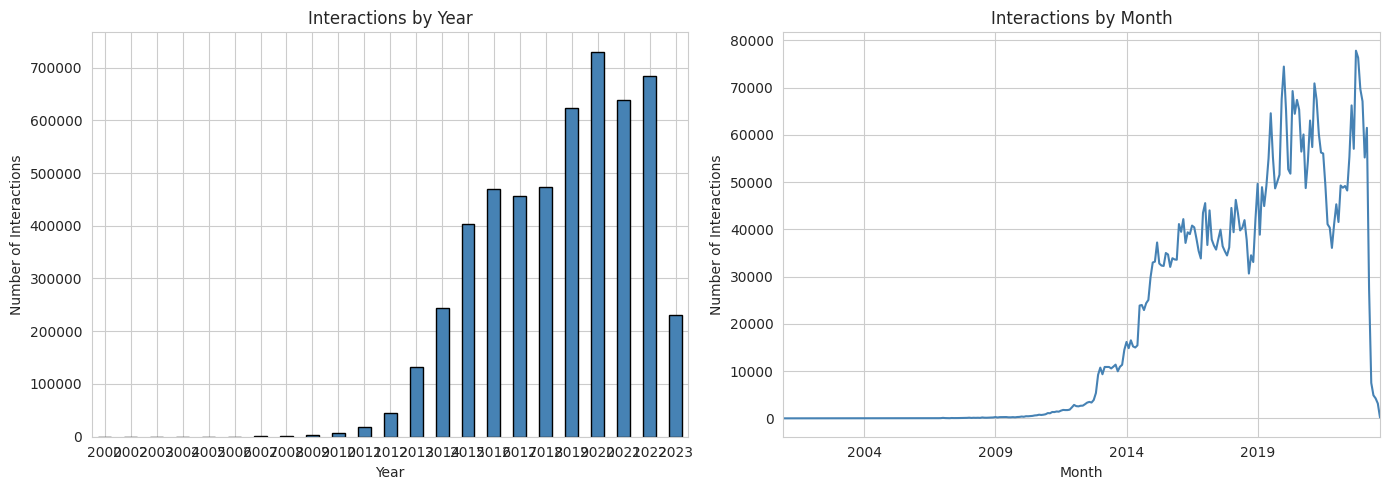

In [16]:
# === Cell 7: Q6 - 时间跨度分析 ===

# timestamp 是毫秒级 Unix 时间戳,转成 datetime
train['datetime'] = pd.to_datetime(train['timestamp'], unit='ms')

print("【时间跨度】")
print(f"  最早交互: {train['datetime'].min()}")
print(f"  最晚交互: {train['datetime'].max()}")
print(f"  时间跨度: {(train['datetime'].max() - train['datetime'].min()).days} 天 (≈ {(train['datetime'].max() - train['datetime'].min()).days / 365:.1f} 年)")
print()

# 按年统计
train['year'] = train['datetime'].dt.year
yearly = train.groupby('year').size()
print("【按年分布】")
for year, count in yearly.items():
    bar = '█' * int(count / yearly.max() * 50)
    print(f"  {year}: {count:>10,}  {bar}")

# 画图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图: 按年
yearly.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Interactions')
axes[0].set_title('Interactions by Year')
axes[0].tick_params(axis='x', rotation=0)

# 右图: 按月
train['year_month'] = train['datetime'].dt.to_period('M')
monthly = train.groupby('year_month').size()
monthly.plot(ax=axes[1], color='steelblue')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Interactions')
axes[1].set_title('Interactions by Month')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [18]:
# === Cell 8: 八股第 8 题预热 - 为什么需要负采样 ===

# 基于刚才的数据,演示负采样的必要性
n_users = train['user_id'].nunique()
n_items = train['parent_asin'].nunique()
n_interactions = len(train)

# 1. 正样本数
positive_samples = (train['rating'] >= 4).sum()

# 2. 理论上的"全部 user-item 对"
total_pairs = n_users * n_items

# 3. 隐含的负样本数(用户没买过的所有商品)
implicit_negatives = total_pairs - n_interactions

print("=" * 60)
print("负采样为什么需要 - 用真实数据说话")
print("=" * 60)
print()
print(f"用户数:         {n_users:>15,}")
print(f"商品数:         {n_items:>15,}")
print(f"理论全部 pair:  {total_pairs:>15,}   ({total_pairs/1e9:.1f} 十亿)")
print()
print(f"实际交互:       {n_interactions:>15,}")
print(f"  - 正样本(≥4): {positive_samples:>15,}   ({positive_samples/n_interactions*100:.1f}%)")
print(f"  - 负样本(<4): {n_interactions-positive_samples:>15,}   ({(n_interactions-positive_samples)/n_interactions*100:.1f}%)")
print()
print(f"隐含的'潜在负样本'(用户没交互过的商品):  {implicit_negatives:>15,}")
print(f"  即:潜在负样本 / 正样本 = {implicit_negatives / positive_samples:.0f} : 1")
print()
print("【关键洞察】")
print("如果不做负采样,正负样本比例 = 1 : 37,000")
print("模型只要'永远预测 0'就能达到 99.997% 的准确率")
print("但这种模型在实际推荐场景毫无用处!")
print()
print("【负采样的本质】")
print("人为构造'平衡的训练数据':")
print("- 正样本: 5★ 4★ 评分 → label=1")  
print("- 负样本: 随机抽样 5-10 倍正样本数量的'用户未交互商品' → label=0")
print("- 让模型学到'喜欢' vs '不喜欢'的边界,而不是'稀疏背景'")

负采样为什么需要 - 用真实数据说话

用户数:                 729,576
商品数:                 207,385
理论全部 pair:  151,303,118,760   (151.3 十亿)

实际交互:             5,165,289
  - 正样本(≥4):       4,108,857   (79.5%)
  - 负样本(<4):       1,056,432   (20.5%)

隐含的'潜在负样本'(用户没交互过的商品):  151,297,953,471
  即:潜在负样本 / 正样本 = 36822 : 1

【关键洞察】
如果不做负采样,正负样本比例 = 1 : 37,000
模型只要'永远预测 0'就能达到 99.997% 的准确率
但这种模型在实际推荐场景毫无用处!

【负采样的本质】
人为构造'平衡的训练数据':
- 正样本: 5★ 4★ 评分 → label=1
- 负样本: 随机抽样 5-10 倍正样本数量的'用户未交互商品' → label=0
- 让模型学到'喜欢' vs '不喜欢'的边界,而不是'稀疏背景'


In [19]:
# === Cell 9: 保存 Day 1 关键统计 ===
import os
os.makedirs("../data/processed", exist_ok=True)

# 保存用户活跃度统计(给 Day 2-5 做特征用)
user_activity = train.groupby('user_id').agg(
    n_interactions=('rating', 'size'),
    mean_rating=('rating', 'mean'),
    last_timestamp=('timestamp', 'max')
).reset_index()
user_activity.to_csv("../data/processed/user_activity.csv", index=False)
print(f"✅ user_activity.csv 保存 ({len(user_activity):,} 行)")

# 保存商品热门度统计(给 Day 2-5 做特征用)
item_popularity = train.groupby('parent_asin').agg(
    n_interactions=('rating', 'size'),
    mean_rating=('rating', 'mean'),
    last_timestamp=('timestamp', 'max')
).reset_index()
item_popularity.to_csv("../data/processed/item_popularity.csv", index=False)
print(f"✅ item_popularity.csv 保存 ({len(item_popularity):,} 行)")

# 保存数据探索的关键数字(给写日志/README 用)
import json
day1_stats = {
    "dataset": "Amazon-Reviews-2023 Beauty_and_Personal_Care 5-core",
    "split": "last_out",
    "train": {
        "n_interactions": int(len(train)),
        "n_users": int(train['user_id'].nunique()),
        "n_items": int(train['parent_asin'].nunique()),
        "sparsity": float(1 - len(train) / (train['user_id'].nunique() * train['parent_asin'].nunique())),
        "rating_dist": {
            "1_star_pct": 7.2,
            "2_star_pct": 4.9,
            "3_star_pct": 8.4,
            "4_star_pct": 13.9,
            "5_star_pct": 65.6,
            "positive_ratio_4plus": 79.5
        },
        "user_activity": {
            "median": 5,
            "mean": 7.08,
            "p90": 12,
            "p99": 39,
            "max": 2349
        },
        "item_popularity": {
            "median": 10,
            "mean": 24.91,
            "p90": 45,
            "p99": 273,
            "max": 5986,
            "top20pct_share": 70.5
        },
        "time_range": {
            "start": "2000-12-20",
            "end": "2023-09-12",
            "span_years": 22.7,
            "peak_year": 2020,
            "peak_year_count": 730202
        }
    }
}

with open("../data/processed/day1_stats.json", "w") as f:
    json.dump(day1_stats, f, indent=2)
print(f"✅ day1_stats.json 保存")

print("\n=== Day 1 数据探索全部完成 ===")

✅ user_activity.csv 保存 (729,576 行)
✅ item_popularity.csv 保存 (207,385 行)
✅ day1_stats.json 保存

=== Day 1 数据探索全部完成 ===
